<a href="https://colab.research.google.com/github/PabloTM-00/PabloTM-00/blob/main/Lab_S02_Analisis_y_Preprocesamiento_Playlist_PabloTorres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**1. Análisis y Procesamiento.**

En este caso se va a trabajar con un dataset propio: mi propia playlist de spotify que incluye metadatos de cada canción (nombre, artista, álbum, género, fecha de lanzamiento) y "audio features" calculadas por el propio Spotify (Danceability, Energy, Valence, Tempo, etc.).

- Cada fila es una canción agregada a la playlist.
- `Popularity` es una puntuación de 0 a 100 que da Spotify
- `Danceability`, `Energy`, `Valence`, etc. son valores entre 0 y 1 calculados algorítmicamente por
Spotify que describen características  de cada tema.

**Variable "foco" de este análisis:** vamos a mirar `Popularity`, separando las canciones en
**Alta popularidad** (`Popularity > 50`) vs **Baja popularidad** (`Popularity <= 50`) (Como Donante vs No Donante del ejemplo de clase)

**Variable numérica a explorar en detalle:** `Danceability` (Cantidad donada del ejemplo de clase)

In [9]:
# Importamos las librerías que vamos a necesitar durante todo el análisis
import pandas as pd   # manejo de datos tabulares (DataFrames)
import numpy as np    # operaciones numéricas y tipos de datos
import matplotlib.pyplot as plt  # generación de gráficos

In [10]:
# Carga de datos
# encoding="utf-8-sig" es importante acá: el CSV exportado por Spotify/Exportify trae un
# caracter invisible (BOM) al principio del archivo que, si no se indica el encoding correcto,
# termina "pegado" al nombre de la primera columna (ej: quedaría como "ï»¿Track URI" en vez de
# "Track URI").
data_frame = pd.read_csv("playlist.csv", encoding="utf-8-sig", low_memory=False)

In [11]:
# Mostramos las primeras filas para tener una primera idea del contenido del dataset
data_frame.head(10)

,Track URI,Track Name,Album Name,Artist Name(s),Release Date,Duration (ms),Popularity,Explicit,Added By,Added At,...,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:0TZJzQCOkVtyzjOD8wzAHh,FATAL FANTASSY,FATAL FANTASSY,Alvaro Diaz;Tainy,2023-10-27,149360.0,48.0,False,u88iadq62r1eebsjfcziz6ymd,2023-10-27T17:14:58Z,...,2.0,-4.730,1.0,0.0499,0.0928,0.000000,0.7730,0.377,124.999,4.0
1,spotify:track:5Sj46dsTWjcgyiWuxGKGul,2030,2030,La Pantera,2024-06-07,122659.0,37.0,True,u88iadq62r1eebsjfcziz6ymd,2024-06-08T17:36:15Z,...,8.0,-4.597,1.0,0.0391,0.2680,0.000003,0.0902,0.845,90.258,4.0
2,spotify:track:6RmnotfWeDu72fXhpo26Bq,otra vez,BAHÍA DUCATI,Feid;Alvaro Diaz,2020-09-11,205000.0,61.0,False,u88iadq62r1eebsjfcziz6ymd,2024-01-25T17:43:25Z,...,9.0,-7.439,1.0,0.0992,0.0199,0.000000,0.1240,0.216,145.903,4.0
3,spotify:track:0tHzUXLKk7p0wzMZMMEl8y,CANIJO,CANIJO,Judeline,2023-06-15,141586.0,57.0,False,u88iadq62r1eebsjfcziz6ymd,2025-07-05T16:29:53Z,...,2.0,-8.496,0.0,0.3490,0.5680,0.000015,0.1740,0.410,84.410,5.0
4,spotify:track:60SnwR5bQXskXxqfSqVDgg,MARGIELA,MARGIELA,Omar Courtz,2022-02-11,171291.0,0.0,False,u88iadq62r1eebsjfcziz6ymd,2023-10-21T09:23:54Z,...,8.0,-7.356,0.0,0.3820,0.3700,0.000015,0.1000,0.656,90.078,4.0
5,spotify:track:7fsQJ46vwtDi5p9DzeRDzB,FANTASMA | AVC,FANTASMA | AVC,Tainy;JHAYCO,2023-06-01,285074.0,59.0,False,u88iadq62r1eebsjfcziz6ymd,2023-10-22T20:15:54Z,...,1.0,-2.686,1.0,0.0980,0.0338,0.000000,0.0985,0.588,98.986,4.0
6,spotify:track:4YnmQG1fnJR9LnTZtix70T,WYA REMIX RED,WYA REMIX RED,J Abdiel;De La Rose;Yan Block;iZaak;Jay Wheeler,2024-05-10,321741.0,79.0,True,u88iadq62r1eebsjfcziz6ymd,2024-05-13T17:55:51Z,...,0.0,-5.985,0.0,0.0486,0.3640,0.000000,0.0999,0.371,110.045,4.0
7,spotify:track:10uuINeqxckcD70rf1h4rg,Mil Días,Lazos y Nudos,ABHIR;Delaossa,2021-05-21,213352.0,47.0,False,u88iadq62r1eebsjfcziz6ymd,2025-02-12T20:53:35Z,...,3.0,-9.940,0.0,0.0616,0.1510,0.043900,0.1400,0.628,113.595,5.0
8,spotify:track:6CTPAEcZHibzE7ojZKGojh,MALAFAMA,PARAÍSO,Mora,2022-11-03,169129.0,51.0,True,u88iadq62r1eebsjfcziz6ymd,2025-05-21T18:02:58Z,...,9.0,-4.977,0.0,0.1300,0.1560,0.000000,0.0908,0.371,89.978,4.0
9,spotify:track:3b9hmdwt0RWluhFm3hLKz8,ROMÁNTICOS DE LUNES,"MOR, No Le Temas a La Oscuridad",Feid,2023-09-29,242840.0,68.0,False,u88iadq62r1eebsjfcziz6ymd,2025-05-27T12:58:03Z,...,4.0,-5.761,1.0,0.0973,0.0699,0.000000,0.0960,0.363,98.903,4.0


**1.1. Antes de Continuar...**

Antes de seguir, conviene tener claro qué significa cada columna. Diccionario de datos:

| Columna              | Descripción                                                              |
|-----------------------|---------------------------------------------------------------------------|
| Track URI             | Identificador único de la canción en Spotify                             |
| Track Name            | Nombre de la canción                                                     |
| Album Name            | Nombre del álbum                                                         |
| Artist Name(s)        | Artista(s), separados por `;` si hay más de uno                          |
| Release Date          | Fecha de lanzamiento                                                     |
| Duration (ms)         | Duración de la canción en milisegundos                                   |
| Popularity             | Popularidad de la canción según Spotify (0 a 100)                       |
| Explicit               | Si la canción tiene contenido explícito (True/False)                    |
| Added By / Added At   | Quién y cuándo agregó la canción a la playlist                           |
| Genres                 | Género(s) del artista                                                    |
| Record Label           | Sello discográfico                                                       |
| Danceability            | Qué tan "bailable" es la canción (0 a 1)                                |
| Energy                  | Intensidad y actividad percibida (0 a 1)                                |
| Key / Mode              | Tonalidad y modo musical (mayor/menor)                                  |
| Loudness                | Volumen promedio en decibeles (dB)                                      |
| Speechiness              | Presencia de palabras habladas (0 a 1)                                  |
| Acousticness             | Qué tan acústica es la canción (0 a 1)                                  |
| Instrumentalness         | Probabilidad de que no tenga voces (0 a 1)                              |
| Liveness                 | Probabilidad de que sea grabación en vivo (0 a 1)                       |
| Valence                  | Positividad/alegría transmitida por la canción (0 a 1)                  |
| Tempo                     | Velocidad de la canción en BPM                                         |
| Time Signature            | Compás musical                                                         |

**Antes de seguir, dale una mirada rápida a `data_frame.head()` de arriba y fijate qué columnas
te parecen más relevantes para lo que quieras explorar.**

**1.2. Análisis General.**

1. Conocer la cantidad de observaciones y la cantidad de características.

2. Averiguar si existen datos nulos.

3. Conocer la cantidad de columnas categóricas y numéricas (recuerde que muchos algoritmos trabajan
   solo con columnas numéricas y, eventualmente, hay que transformarlas).

In [12]:
# ESTA FUNCIÓN NOS MUESTRA LA ESTRUCTURA DEL DATASET
# shape devuelve una tupla (cantidad_de_filas, cantidad_de_columnas)
data_frame.shape

(1227, 24)

In [13]:
# ESTA CELDA EVALÚA SI EXISTEN VALORES NULOS EN EL DATASET
# isnull() marca con True/False cada celda según si es nula
# .any() por columna: True si ESA columna tiene al menos un nulo
# .any() (el segundo) sobre el resultado anterior: True si HAY al menos una columna con nulos
data_frame.isnull().any().any()

np.True_

In [14]:
# Para ver el detalle de CUÁNTOS nulos tiene cada columna (más informativo que el .any().any())
data_frame.isnull().sum().sort_values(ascending=False)

,0
Genres,456
Release Date,12
Acousticness,12
Speechiness,12
Danceability,12
Energy,12
Key,12
Loudness,12
Liveness,12
Valence,12


_✍️ Tu análisis acá:_

¿Qué columnas tienen más valores nulos? ¿Te parece razonable? Por ejemplo, `Genres` suele
tener nulos cuando el artista no tiene géneros catalogados en Spotify. Anotá acá tus observaciones.

In [15]:
# Agrupación de las columnas por tipo de datos
# select_dtypes separa las columnas según si son numéricas o de texto (categóricas)
ctext = data_frame.select_dtypes(include="object").columns   # columnas categóricas (texto)
cnum = data_frame.select_dtypes(include="number").columns    # columnas numéricas

print("Columnas categóricas:", list(ctext))
print("Cantidad:", len(ctext))

Columnas categóricas: ['Track URI', 'Track Name', 'Album Name', 'Artist Name(s)', 'Release Date', 'Explicit', 'Added By', 'Added At', 'Genres', 'Record Label']
Cantidad: 10


In [16]:
# Columnas numéricas
print("Columnas numéricas:", list(cnum))
print("Cantidad:", len(cnum))

Columnas numéricas: ['Duration (ms)', 'Popularity', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Time Signature']
Cantidad: 14


**1.3. Tratamiento de los Nulos.**

En el análisis anterior quedó en evidencia la existencia de valores nulos, razón por la cual hay
que tratarlos antes de continuar.

In [17]:
# Completando valores faltantes de las columnas numéricas
# Estrategia simple: reemplazar cada nulo por el PROMEDIO de esa columna.
for columna in cnum:
    mean = data_frame[columna].mean()
    data_frame[columna] = data_frame[columna].fillna(mean)

In [18]:
# Completando valores faltantes de las columnas categóricas
# Estrategia simple: reemplazar cada nulo por la MODA (el valor más frecuente) de esa columna.
for columna in ctext:
    mode = data_frame[columna].mode()[0]
    data_frame[columna] = data_frame[columna].fillna(mode)

/tmp/ipykernel_1015/1558231802.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_frame[columna] = data_frame[columna].fillna(mode)


In [19]:
# Se vuelve a comprobar los nulos: debería devolver False si ya no quedan valores faltantes
data_frame.isnull().any().any()

np.False_

In [20]:
# Guardando el dataset preprocesado en un nuevo CSV, listo para ser usado en pasos posteriores
data_frame.to_csv("playlist_procesado.csv", index=False)

In [21]:
# Creamos la variable "foco" del análisis: si la canción es de Alta o Baja popularidad
# (equivalente a DONOR_FLAG del ejemplo original)
data_frame['Alta_Popularidad'] = data_frame['Popularity'] > 50

# Calculamos qué porcentaje de canciones son de alta popularidad
porcent_alta_pop = (
    data_frame[data_frame['Alta_Popularidad']]['Alta_Popularidad'].count() * 1.0
    / data_frame['Alta_Popularidad'].count()
) * 100.0

print("El porcentaje de canciones de alta popularidad es {0:.2f}%".format(porcent_alta_pop))

El porcentaje de canciones de alta popularidad es 48.66%


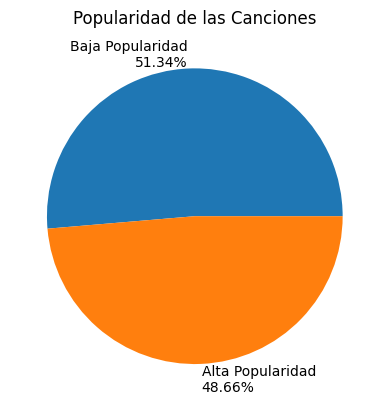

In [22]:
# Gráfico de torta del porcentaje de canciones de alta vs baja popularidad

# Agrupando por Alta_Popularidad y contando canciones
conteo_pop = data_frame.groupby('Alta_Popularidad')['Track URI'].count()

# Creando las leyendas del gráfico con el porcentaje que representa cada porción
labels = [
    ('Alta Popularidad\n' if flag else 'Baja Popularidad\n')
    + str(round(x * 1.0 / conteo_pop.sum() * 100.0, 2)) + '%'
    for flag, x in conteo_pop.items()
]

plt.pie(conteo_pop, labels=labels)
plt.title('Popularidad de las Canciones')
plt.show()

_✍️ Tu análisis acá:_

¿Qué proporción de tu playlist es de alta vs baja popularidad? ¿Te sorprende el resultado?
¿Qué implicancias tendría este balance de clases si quisieras entrenar un modelo que prediga si una
canción va a ser popular o no?

**1.4. Trabajando con Filtros.**

In [23]:
# Creando un subset con solo las canciones de alta popularidad
data_populares = data_frame[data_frame['Alta_Popularidad']]
data_populares.shape

(597, 25)

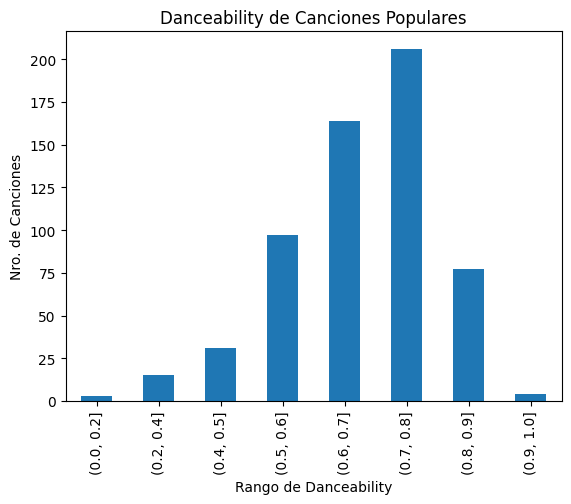

In [24]:
# Analizando la Danceability de las canciones populares

# Creando segmentos (rangos) de danceability con pd.cut (recordá que Danceability va de 0 a 1)
segm = pd.cut(data_populares['Danceability'], [0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# Creando el gráfico de barras desde pandas con la cantidad de canciones por rango
plot = segm.value_counts().sort_index().plot(kind='bar', title='Danceability de Canciones Populares')
plot.set_ylabel('Nro. de Canciones')
plot.set_xlabel('Rango de Danceability')
plt.show()

_✍️ Tu análisis acá:_

¿En qué rango se concentra la mayoría de tus canciones populares? ¿Te parece que tu playlist
es en general "bailable" o no?

In [25]:
# Agrupación por segmento según Danceability
segm.value_counts().sort_index()

,count
Danceability,
"(0.0, 0.2]",3
"(0.2, 0.4]",15
"(0.4, 0.5]",31
"(0.5, 0.6]",97
"(0.6, 0.7]",164
"(0.7, 0.8]",206
"(0.8, 0.9]",77
"(0.9, 1.0]",4


**1.4.1. Responder Algunas Preguntas.**

**1.4.2. ¿Cuál es el promedio de Danceability de las canciones populares?**

In [26]:
# Danceability promedio de las canciones populares
data_populares['Danceability'].mean()

np.float64(0.6753819288486327)

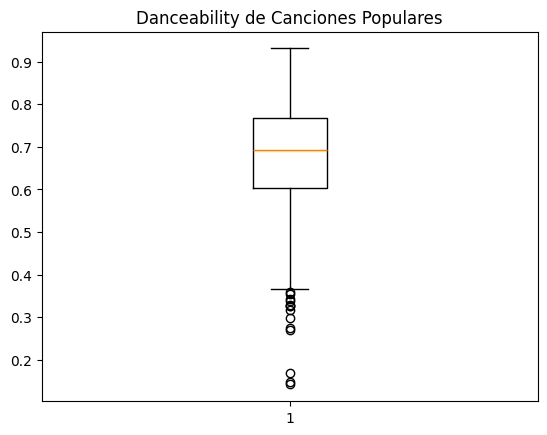

In [27]:
# Gráfico de cajas (boxplot) de la Danceability de las canciones populares
plt.boxplot(list(data_populares['Danceability']))
plt.title('Danceability de Canciones Populares')
plt.show()

_✍️ Tu análisis acá:_

Mirando el boxplot: ¿hay valores atípicos (outliers)? ¿La mediana está cerca del promedio o
hay asimetría? ¿Qué conclusión sacás?

**1.4.3. ¿Cuál es la distribución de canciones explícitas entre las populares?**

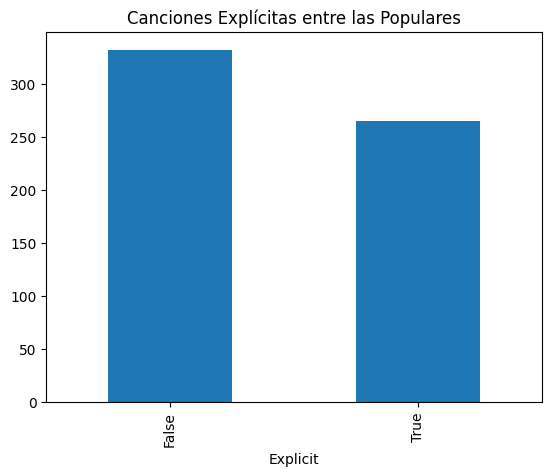

In [28]:
# Gráfico de la cantidad de canciones explícitas vs no explícitas, entre las populares
data_populares.groupby('Explicit')['Track URI'].count().plot(kind='bar')
plt.title('Canciones Explícitas entre las Populares')
plt.show()

**1.4.4. ¿Cuál es la Danceability según si la canción es explícita o no?**

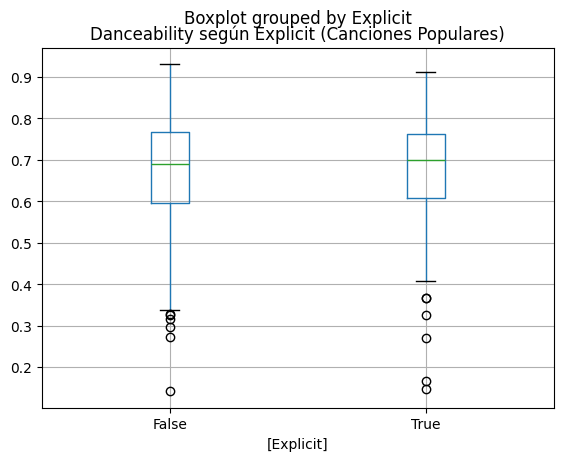

In [29]:
# Danceability según si la canción es explícita, dentro de las canciones populares
data_populares[
    data_populares.Explicit.isin([True, False])
][['Danceability', 'Explicit']].boxplot(by='Explicit')
plt.title('Danceability según Explicit (Canciones Populares)')
plt.show()

In [30]:
# Danceability promedio de canciones explícitas (dentro de las populares)
data_populares[data_populares.Explicit == True][['Danceability']].mean()

,0
Danceability,0.676026


In [31]:
# Danceability promedio de canciones NO explícitas (dentro de las populares)
data_populares[data_populares.Explicit == False][['Danceability']].mean()

,0
Danceability,0.674868


_✍️ Tu análisis acá:_

¿Las canciones explícitas de tu playlist tienden a ser más o menos bailables que las que no
lo son? ¿A qué le atribuís esa diferencia (si es que existe)?

**1.4.5. ¿Cuál es la distribución de las canciones según el año de lanzamiento?**

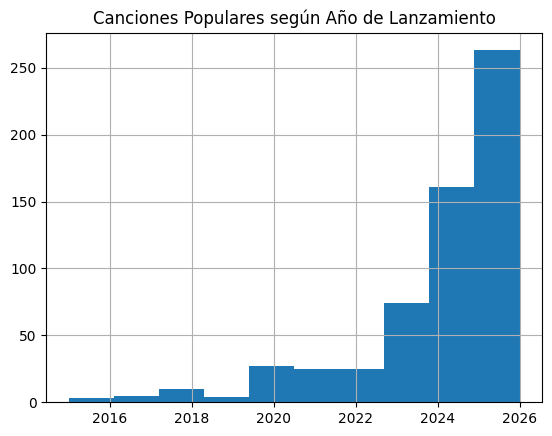

In [32]:
# Extraemos el año a partir de la columna Release Date
# errors="coerce" convierte a NaT (nulo) las fechas que no se puedan interpretar, en vez de fallar
data_populares = data_populares.copy()
data_populares['Release Year'] = pd.to_datetime(
    data_populares['Release Date'], errors='coerce'
).dt.year

data_populares['Release Year'].hist()
plt.title('Canciones Populares según Año de Lanzamiento')
plt.show()

_✍️ Tu análisis acá:_

¿La mayoría de tus canciones populares son recientes o hay una mezcla amplia de épocas?
¿Esto tiene sentido con el tipo de playlist que armaste?

**1.4.6. Trabajo Futuro...**

En las próximas experiencias es posible continuar con este ejemplo completando los restantes
pasos que incluye un proyecto de Minería de Datos hasta llegar a un modelo: por ejemplo, entrenar un
clasificador que prediga `Alta_Popularidad` a partir de las audio features (`Danceability`, `Energy`,
`Valence`, `Tempo`, etc.), siguiendo los pasos de selección de atributos, armado de modelo,
entrenamiento, evaluación, métricas y predicción.

**Para vos:** ¿qué otras preguntas te gustaría responder con este dataset? Algunas ideas:
- ¿Qué géneros predominan en tu playlist?
- ¿Hay relación entre Energy y Valence (canciones intensas vs. canciones "felices")?
- ¿Quién agregó más canciones a la playlist (`Added By`) y qué tan popular es lo que agrega?